In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.stats as st

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

matplotlib.rcParams['pdf.fonttype'] = 42


In [2]:
import pickle
# Load color palette
with open('../data/cell_type_palette.pkl', 'rb') as f:
    cell_type_palette = pickle.load(f)

In [3]:
mrvi_adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/mrvi_jak2_heterozygous_included.h5ad')


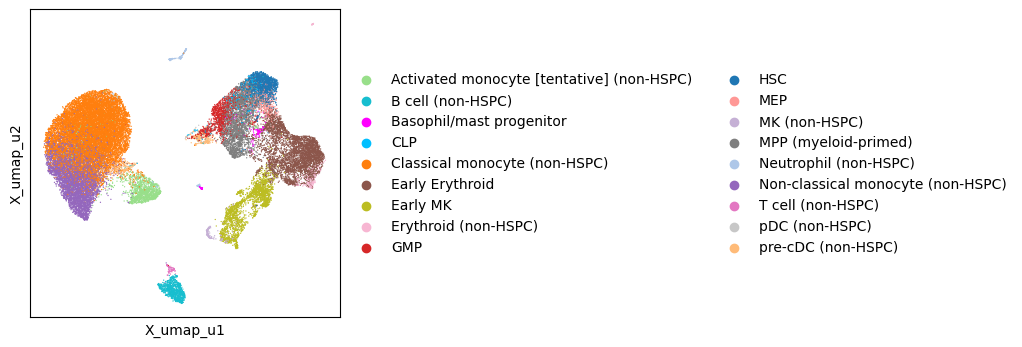

In [4]:
fig,ax = plt.subplots(figsize=(4,4))
sc.pl.embedding(mrvi_adata, color = 'cell_type', basis='X_umap_u', ax=ax, show=False, title='', palette=cell_type_palette)
# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/mrvi_het_u_cell_types.pdf', dpi=300, bbox_inches='tight')

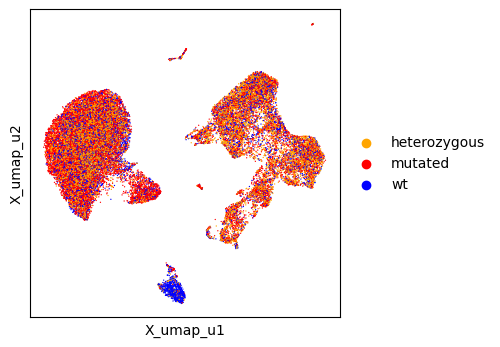

In [5]:
fig,ax = plt.subplots(figsize=(4,4))
sc.pl.embedding(mrvi_adata, color = 'genotype', basis='X_umap_u', ax=ax, show=False, title='', palette = {'mutated':'red','heterozygous':'orange','wt':'blue'})
# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/mrvi_het_u_genotype.pdf', dpi=300, bbox_inches='tight')

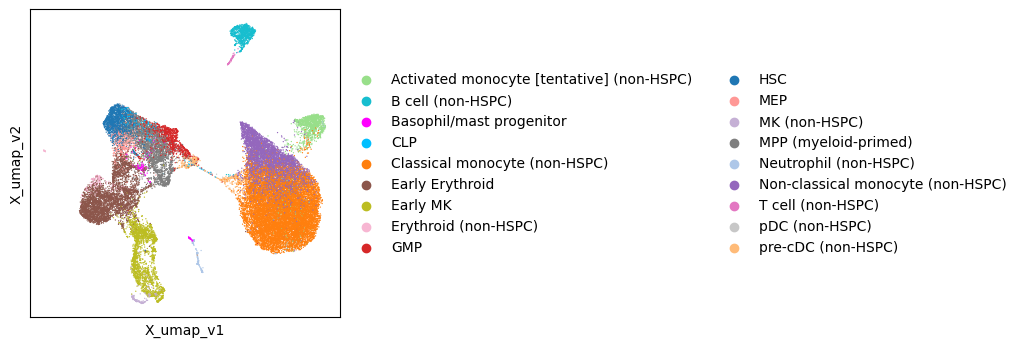

In [6]:
fig,ax = plt.subplots(figsize=(4,4))
sc.pl.embedding(mrvi_adata, color = 'cell_type', basis='X_umap_v', ax=ax, show=False, title='', palette=cell_type_palette)
# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/mrvi_het_z_cell_types.pdf', dpi=300, bbox_inches='tight')

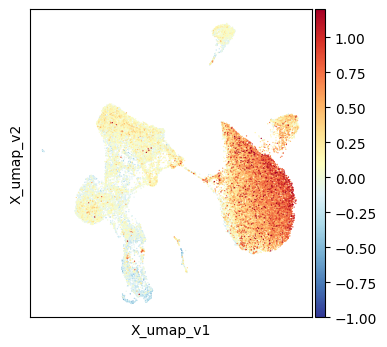

In [8]:
gene_set = pd.read_csv('../../5_figure_MPN_JAK2/data/HALLMARK_INTERFERON_GAMMA_RESPONSE.v2025.1.Hs.tsv', sep='\t',index_col=0).loc['GENE_SYMBOLS'].values[0].split(',')
genes_present = []
for gene_name in gene_set:
    if gene_name in mrvi_adata.var_names:
        genes_present.append(gene_name)
geneset_id = [mrvi_adata.var_names.get_loc(j) for j in genes_present]

mrvi_adata.obs['ifn_gamma_score'] = np.mean(mrvi_adata.layers['zs_norm_log'][:, geneset_id], axis = 1)

fig,ax = plt.subplots(figsize=(4,4))
sc.pl.embedding(mrvi_adata, color = 'ifn_gamma_score', basis='X_umap_v', ax=ax, show=False, title = '', cmap = 'RdYlBu_r', vmin=-1, vmax=1.2)

# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/mrvi_het_z_ifn_gamma_score.pdf', dpi=300, bbox_inches='tight')